# 🤖 ML Practice Project — Employee Salary Prediction

### Dataset

In [38]:
import pandas as pd
import numpy as np

employees = {
    "Age": [22, 24, 27, 29, 31, 26, 35, 30, 28, 33, 25, 32, 29, 36, 27, 34],
    
    "Experience": [1, 2, 3, 5, 7, 4, 10, 6, 3, 8, 2, 9, 5, 11, 4, 7],
    
    "Performance": [
        68, 72, 78, 85,
        91, 80, 97, 88,
        75, 94, 73, 92,
        86, 98, 81, 90
    ],
    
    "Projects": [
        1, 2, 3, 4,
        6, 3, 9, 5,
        2, 7, 2, 8,
        5, 10, 4, 7
    ],
    
    "Salary": [
        45000, 49000, 56000, 67000,
        82000, 61000, 120000, 76000,
        54000, 100000, 50000, 110000,
        73000, 135000, 63000, 92000
    ]
}

df = pd.DataFrame(employees)

print(df)

    Age  Experience  Performance  Projects  Salary
0    22           1           68         1   45000
1    24           2           72         2   49000
2    27           3           78         3   56000
3    29           5           85         4   67000
4    31           7           91         6   82000
5    26           4           80         3   61000
6    35          10           97         9  120000
7    30           6           88         5   76000
8    28           3           75         2   54000
9    33           8           94         7  100000
10   25           2           73         2   50000
11   32           9           92         8  110000
12   29           5           86         5   73000
13   36          11           98        10  135000
14   27           4           81         4   63000
15   34           7           90         7   92000


### Task 1 — Inspect

In [39]:
print(df.head())
print(df.tail())
print(df.shape)
print(df.dtypes)

   Age  Experience  Performance  Projects  Salary
0   22           1           68         1   45000
1   24           2           72         2   49000
2   27           3           78         3   56000
3   29           5           85         4   67000
4   31           7           91         6   82000
    Age  Experience  Performance  Projects  Salary
11   32           9           92         8  110000
12   29           5           86         5   73000
13   36          11           98        10  135000
14   27           4           81         4   63000
15   34           7           90         7   92000
(16, 5)
Age            int64
Experience     int64
Performance    int64
Projects       int64
Salary         int64
dtype: object


### Task 2 — EDA

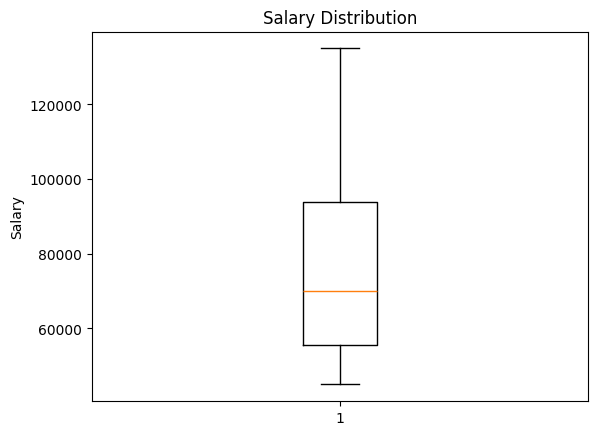

In [40]:
import matplotlib.pyplot as plt

plt.boxplot(df["Salary"])

plt.ylabel("Salary")
plt.title("Salary Distribution")

plt.show()

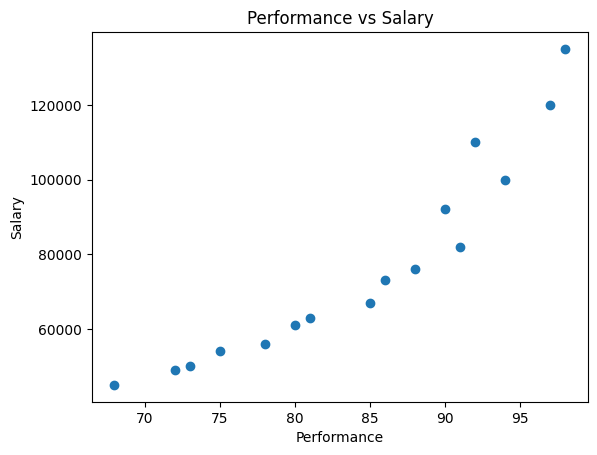

In [41]:
plt.scatter(df["Performance"], df["Salary"])

plt.xlabel("Performance")
plt.ylabel("Salary")
plt.title("Performance vs Salary")

plt.show()

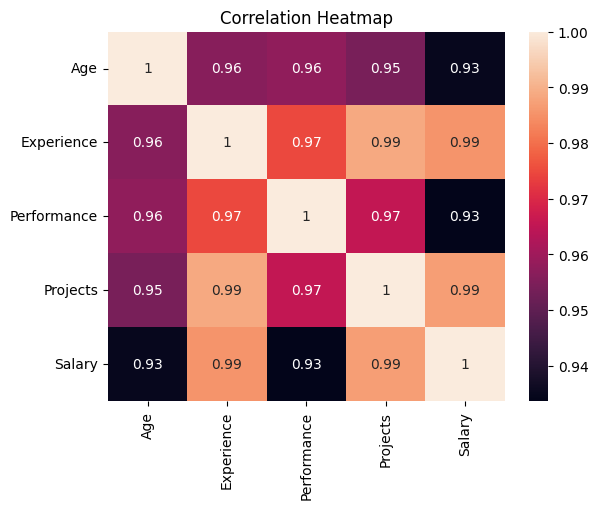

In [42]:
import seaborn as sns

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")

plt.show()

### Task 3 — Define the ML Problem

In [43]:
x = df[["Age", "Experience", "Performance", "Projects"]]
y = df["Salary"]

### Task 4 — Train/Test Split

In [44]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

### Task 5 — Train a Linear Regression Model

In [45]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
train_prediction = model.predict(x_train)
test_prediction = model.predict(x_test)

print("Train Data Actual: ", y_train.values)
print("Train Data Prediction: ", train_prediction.round(2))
print()
print("Test Data Actual: ", y_test.values)
print("Test Data Prediction: ", test_prediction.round(2))

Train Data Actual:  [135000 110000  54000 100000  56000  92000  82000  76000  50000  73000
  67000 120000]
Train Data Prediction:  [132423.67 112690.52  54016.31  95890.46  55610.56  94818.49  86023.88
  76415.68  48827.42  71743.53  66807.47 119732.02]

Test Data Actual:  [45000 49000 61000 63000]
Test Data Prediction:  [41785.91 50110.77 59765.96 64960.39]


### Task 7 — Evaluate

In [47]:
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(y_train, train_prediction)
test_mae = mean_absolute_error(y_test, test_prediction)

from sklearn.metrics import mean_squared_error

train_mse = mean_squared_error(y_train, train_prediction)
test_mse = mean_squared_error(y_test, test_prediction)

from sklearn.metrics import root_mean_squared_error

train_rmse = root_mean_squared_error(y_train, train_prediction)
test_rmse = root_mean_squared_error(y_test, test_prediction)

from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, train_prediction)
test_r2 = r2_score(y_test, test_prediction)

In [48]:
results = {
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train MSE": train_mse,
    "Test MSE": test_mse,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse,
    "Train R2": train_r2,
    "Test R2": test_r2,
}

print(results)

{'Train MAE': 1660.8119286259134, 'Test MAE': 1879.8221019046687, 'Train MSE': 4857289.417426726, 'Test MSE': 4232541.960964041, 'Train RMSE': 2203.9259101491425, 'Test RMSE': 2057.314259165099, 'Train R2': 0.9928977622928886, 'Test R2': 0.9279567325793354}


### Task 8 — Model Comparison 🔥

In [49]:
x_single = df[["Experience"]]
y_single = df["Salary"]

x_train, x_test, y_train, y_test = train_test_split(
    x_single,
    y_single,
    test_size=0.2,
    random_state=42
)

model.fit(x_train, y_train)

single_prediction = model.predict(x_test)

single_mae = mean_absolute_error(y_test, single_prediction)
single_rmse = root_mean_squared_error(y_test, single_prediction)
single_r2 = r2_score(y_test, single_prediction)

In [50]:
print("Mutlti Feature MAE: ", test_mae)
print("Single Feature MAE: ", single_mae)
print()
print("Mutlti Feature RMSE: ", test_rmse)
print("Single Feature RMSE: ", single_rmse)
print()
print("Mutlti Feature R2: ", test_r2)
print("Single Feature R2: ", single_r2)

Mutlti Feature MAE:  1879.8221019046687
Single Feature MAE:  4382.352941176474

Mutlti Feature RMSE:  2057.314259165099
Single Feature RMSE:  5874.130282381768

Mutlti Feature R2:  0.9279567325793354
Single Feature R2:  0.41267393064860414


### Task 9 — Coefficients

In [51]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

model.fit(x_train, y_train)

for feature, coefficients in zip(x.columns, model.coef_):
    print(feature, ": ", coefficients)

Age :  258.3712011344204
Experience :  7497.212285281516
Performance :  -1541.7190370298722
Projects :  6477.778852041634


### Task 10 — Prediction Test

In [52]:
new_employee = pd.DataFrame({
    "Age": [30],
    "Experience": [6],
    "Performance": [88],
    "Projects": [5]
})

new_predict = model.predict(new_employee)
print(new_predict.round(2))

[76415.68]
